# Cluster Analysis: Economic Factors x Sumber Sampah (2024)

Mengelompokkan kabupaten/kota berdasarkan profil ekonomi (PDRB, pertumbuhan, kepadatan penduduk)  
dan sumber sampah (rumah tangga, perkantoran, perniagaan, pasar, fasilitas publik, dll).

**Data:**
- Sumber Sampah: `data/raw/master_sumber_sipsn_new.xlsx` (SIPSN KLHK)
- Ekonomi: `data/bps_economic_kabkota.csv` (BPS)

**Tahun:** 2024

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

## 1. Load Data

In [2]:
BASE = '../data'

sumber_raw = pd.read_excel(f'{BASE}/raw/master_sumber_sipsn_new.xlsx')
sumber_raw.columns = sumber_raw.columns.str.strip().str.lower()

econ_raw = pd.read_csv(f'{BASE}/bps_economic_kabkota.csv')

print('Sumber shape:', sumber_raw.shape)
print('Economic shape:', econ_raw.shape)

Sumber shape: (1224, 11)
Economic shape: (1542, 10)


## 2. Filter Tahun 2024

In [3]:
sumber = sumber_raw[sumber_raw['tahun'] == 2024].copy()
econ = econ_raw[econ_raw['tahun'] == 2024].copy()

SUMBER_COLS = ['rumah_tangga', 'perkantoran', 'perniagaan', 'pasar', 'fasilitas_publik', 'lainnya']

# Drop rows where ALL sumber cols are NaN (non-reporters)
sumber = sumber[~sumber[SUMBER_COLS].isnull().all(axis=1)].copy()

print(f'Sumber 2024 (usable): {len(sumber)}')
print(f'Economic 2024: {len(econ)}')

Sumber 2024 (usable): 231
Economic 2024: 514


## 3. Normalisasi Nama Kabupaten/Kota

Sumber pakai format `Kab. Bandung` / `Kota Bandung`,  
Economic pakai `Bandung` saja. Perlu dinormalisasi agar bisa di-join.

In [4]:
# Spelling corrections for known mismatches
SPELLING_MAP = {
    'batanghari': 'batang hari',
    'bau bau': 'baubau',
    'gunungkidul': 'gunung kidul',
    'kep siau tagulandang biaro': 'siau tagulandang biaro',
    'makassar': 'makasar',
    'palangkaraya': 'palangka raya',
    'tulang bawang': 'tulangbawang',
}

def normalize_name(name):
    """Strip Kab./Kota prefix, lowercase, normalize spacing and spelling."""
    s = str(name).strip()
    # Remove admin prefixes
    s = re.sub(r'^(Kab\.?\s*Adm\.?\s*|Kabupaten\s+|Kab\.?\s+|Kota\s+)', '', s, flags=re.IGNORECASE)
    s = s.strip().lower()
    # Remove punctuation, normalize whitespace
    s = re.sub(r'[^\w\s]', ' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    # Apply spelling fixes
    s = SPELLING_MAP.get(s, s)
    return s

sumber['kabkota_norm'] = sumber['kabkota'].apply(normalize_name)
econ['kabkota_norm'] = econ['kabkota'].apply(normalize_name)

# Quick check
print('Sumber sample:', sumber[['kabkota', 'kabkota_norm']].head(3).to_string(index=False))
print('Econ sample:  ', econ[['kabkota', 'kabkota_norm']].head(3).to_string(index=False))

Sumber sample:            kabkota  kabkota_norm
 Kab. Aceh Selatan  aceh selatan
Kab. Aceh Tenggara aceh tenggara
   Kab. Aceh Timur    aceh timur
Econ sample:        kabkota kabkota_norm
    Simeulue     simeulue
Aceh Singkil aceh singkil
Aceh Selatan aceh selatan


## 4. Merge Datasets

In [5]:
ECON_COLS = ['pdrb_perkapita_juta', 'pdrb_growth_pct', 'kepadatan']

merged = sumber.merge(
    econ[['kabkota_norm', 'kabkota'] + ECON_COLS],
    on='kabkota_norm',
    how='inner',
    suffixes=('_sumber', '_econ')
)

# Use econ name as canonical
merged['kabkota_display'] = merged['kabkota_econ']

print(f'Matched: {len(merged)} kabupaten/kota')

# Show unmatched
unmatched = set(sumber['kabkota_norm']) - set(econ['kabkota_norm'])
if unmatched:
    print(f'Unmatched ({len(unmatched)}): {sorted(unmatched)}')

Matched: 256 kabupaten/kota
Unmatched (1): ['pasangkayu']


In [6]:
# Fill partial NaN in sumber cols with 0
# Rationale: jika kabkota sudah melapor tapi kolom tertentu NaN,
# artinya daerah tsb memang tidak punya sumber sampah jenis itu
merged[SUMBER_COLS] = merged[SUMBER_COLS].fillna(0)

print('=== NaN check after fill ===')
print(merged[SUMBER_COLS + ECON_COLS].isnull().sum())
print(f'\nFinal dataset: {len(merged)} rows x {len(SUMBER_COLS) + len(ECON_COLS)} features')

=== NaN check after fill ===
rumah_tangga           0
perkantoran            0
perniagaan             0
pasar                  0
fasilitas_publik       0
lainnya                0
pdrb_perkapita_juta    0
pdrb_growth_pct        0
kepadatan              0
dtype: int64

Final dataset: 256 rows x 9 features


In [7]:
merged[['kabkota_display', 'provinsi'] + SUMBER_COLS + ECON_COLS].head(10)

,kabkota_display,provinsi,rumah_tangga,perkantoran,perniagaan,pasar,fasilitas_publik,lainnya,pdrb_perkapita_juta,pdrb_growth_pct,kepadatan
0,Aceh Selatan,Aceh,1.10,0.95,5.65,6.00,5.95,0.00,16.902669,3.213701,81.0
1,Aceh Tenggara,Aceh,20.00,14.00,8.00,25.00,8.00,0.00,30.274760,3.593844,49.0
2,Aceh Timur,Aceh,18.00,5.00,9.00,12.00,5.00,0.00,74.630802,4.631995,71.0
3,Aceh Tengah,Aceh,16.00,7.00,11.00,18.00,10.00,30.00,24.983327,4.984740,149.0
4,Aceh Barat,Aceh,56.65,5.50,10.65,21.60,2.95,2.40,31.985099,7.720900,140.0
5,Aceh Besar,Aceh,48.20,2.70,12.10,19.60,4.30,5.30,29.720535,4.954863,229.0
6,Pidie,Aceh,6.08,4.05,0.00,24.30,2.43,3.65,153.076162,4.145417,52.0
7,Aceh Utara,Aceh,150.00,2.00,20.32,112.00,10.00,3.00,66.600502,3.670942,252.0
8,Simeulue,Aceh,13.70,5.48,8.68,11.42,3.20,1.37,13.445308,4.427605,56.0
9,Aceh Singkil,Aceh,34.00,0.30,5.00,12.00,0.60,1.00,15.080881,3.460825,55.0


## 5. Preprocessing: Log Transform + Standardisasi

Data sumber sampah dan ekonomi sangat skewed (beberapa kabkota punya nilai ribuan kali lipat dari median).  
Log transform (`log1p`) digunakan untuk menekan efek outlier agar clustering lebih bermakna.

In [8]:
FEATURES = SUMBER_COLS + ECON_COLS

# Drop any remaining NaN rows (e.g. missing econ data)
df_clean = merged.dropna(subset=FEATURES).copy()
print(f'Rows after dropna: {len(df_clean)}')

# Log transform skewed features (all except growth rate which can be negative)
LOG_COLS = [c for c in FEATURES if c != 'pdrb_growth_pct']
for col in LOG_COLS:
    df_clean[f'{col}_log'] = np.log1p(df_clean[col])

FEATURES_SCALED = [f'{c}_log' if c in LOG_COLS else c for c in FEATURES]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean[FEATURES_SCALED])

print(f'Feature matrix: {X_scaled.shape}')
print(f'Features (log-transformed): {FEATURES_SCALED}')

# Show before/after skewness
print('\n=== Skewness comparison ===')
for orig, trans in zip(FEATURES, FEATURES_SCALED):
    sk_before = df_clean[orig].skew()
    sk_after = df_clean[trans].skew() if trans != orig else sk_before
    marker = ' << log applied' if trans != orig else ''
    print(f'  {orig:25s} before={sk_before:6.2f}  after={sk_after:6.2f}{marker}')

Rows after dropna: 256
Feature matrix: (256, 9)
Features (log-transformed): ['rumah_tangga_log', 'perkantoran_log', 'perniagaan_log', 'pasar_log', 'fasilitas_publik_log', 'lainnya_log', 'pdrb_perkapita_juta_log', 'pdrb_growth_pct', 'kepadatan_log']

=== Skewness comparison ===
  rumah_tangga              before=  9.20  after=  0.55 << log applied
  perkantoran               before= 15.35  after=  1.68 << log applied
  perniagaan                before= 13.82  after=  1.43 << log applied
  pasar                     before= 13.89  after=  1.11 << log applied
  fasilitas_publik          before=  9.70  after=  1.48 << log applied
  lainnya                   before=  8.08  after=  1.29 << log applied
  pdrb_perkapita_juta       before=  8.00  after=  0.51 << log applied
  pdrb_growth_pct           before=  7.16  after=  7.16
  kepadatan                 before=  3.14  after= -0.37 << log applied


## 6. Optimal K: Elbow Method + Silhouette Score

K=2 cenderung trivial (hanya membagi urban vs rural).  
Kita evaluasi K=3 hingga K=10 untuk mencari segmentasi yang lebih bermakna.

  K=3: silhouette=0.2177  sizes=[145, 108, 3]
  K=4: silhouette=0.1839  sizes=[134, 3, 47, 72]
  K=5: silhouette=0.1855  sizes=[125, 3, 3, 79, 46]
  K=6: silhouette=0.1881  sizes=[46, 40, 64, 3, 100, 3]
  K=7: silhouette=0.1775  sizes=[72, 31, 3, 48, 44, 3, 55]
  K=8: silhouette=0.1676  sizes=[64, 3, 49, 28, 44, 3, 26, 39]
  K=9: silhouette=0.1686  sizes=[29, 64, 3, 14, 47, 29, 44, 1, 25]
  K=10: silhouette=0.1618  sizes=[43, 12, 3, 38, 59, 1, 14, 33, 29, 24]


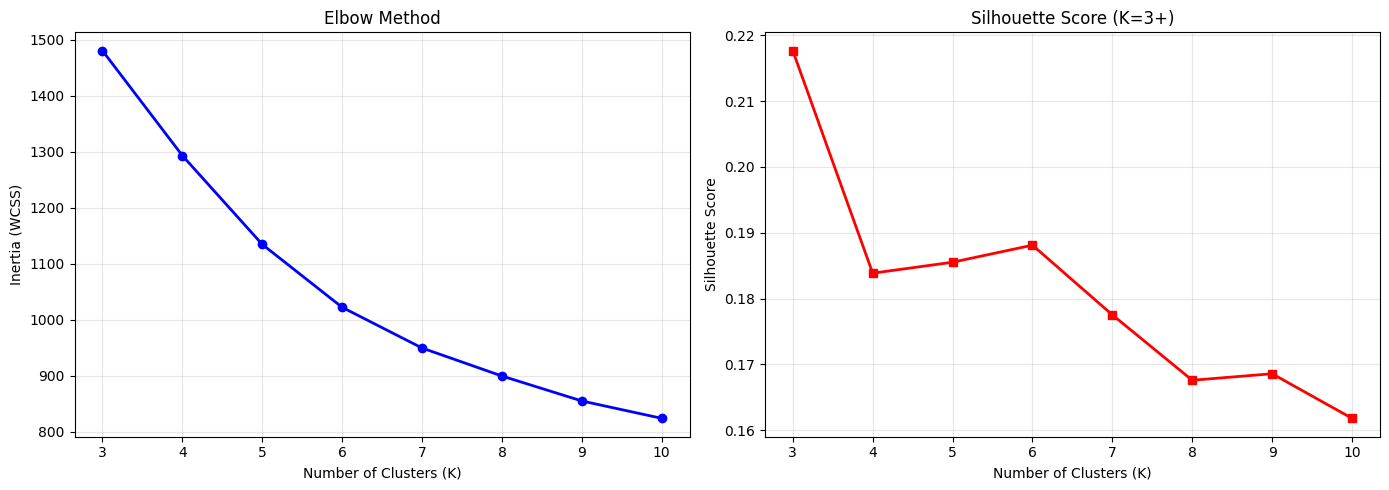


Best K by silhouette (K>=3): 3 (score: 0.2177)


In [9]:
K_RANGE = range(3, 11)
inertias = []
silhouettes = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled, labels)
    silhouettes.append(sil)
    sizes = pd.Series(labels).value_counts().sort_index().tolist()
    print(f'  K={k}: silhouette={sil:.4f}  sizes={sizes}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(K_RANGE, inertias, 'bo-', linewidth=2)
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia (WCSS)')
ax1.set_title('Elbow Method')
ax1.set_xticks(list(K_RANGE))
ax1.grid(True, alpha=0.3)

ax2.plot(K_RANGE, silhouettes, 'rs-', linewidth=2)
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score (K=3+)')
ax2.set_xticks(list(K_RANGE))
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_k = list(K_RANGE)[np.argmax(silhouettes)]
print(f'\nBest K by silhouette (K>=3): {best_k} (score: {max(silhouettes):.4f})')

## 7. Final Clustering

In [10]:
# Override K here
CHOSEN_K = 4

km_final = KMeans(n_clusters=CHOSEN_K, n_init=20, random_state=42)
df_clean['cluster'] = km_final.fit_predict(X_scaled)

print(f'Clustering with K={CHOSEN_K}')
print(f'Silhouette score: {silhouette_score(X_scaled, df_clean["cluster"]):.4f}')
print(f'\nCluster sizes:')
print(df_clean['cluster'].value_counts().sort_index())

Clustering with K=4
Silhouette score: 0.1839

Cluster sizes:
cluster
0    134
1      3
2     47
3     72
Name: count, dtype: int64


## 8. Silhouette Plot per Cluster

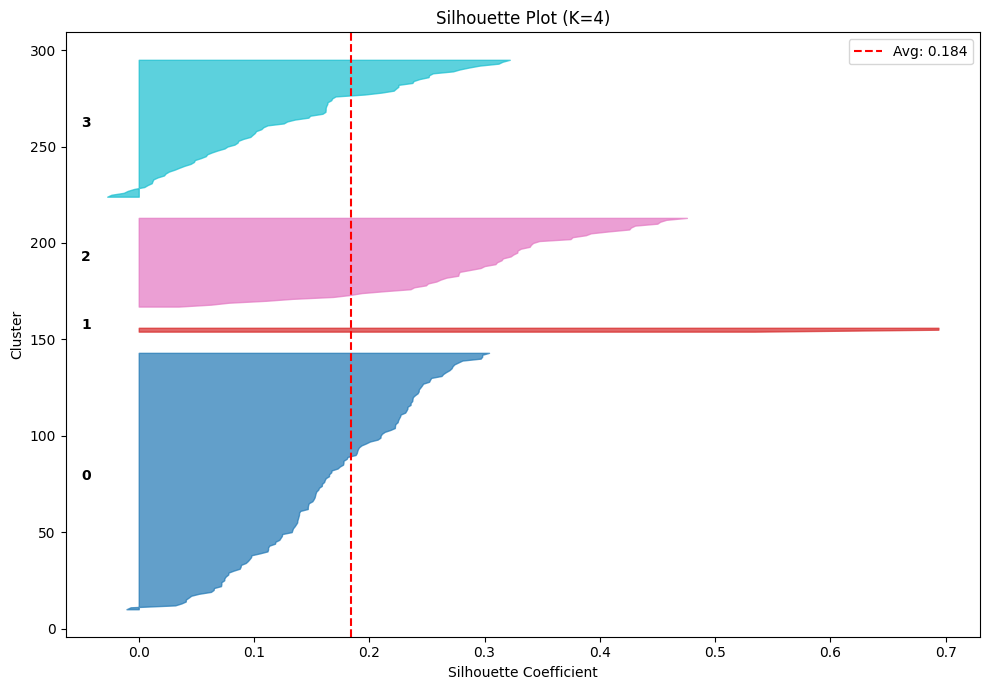

In [11]:
sample_silhouette_values = silhouette_samples(X_scaled, df_clean['cluster'])
avg_score = silhouette_score(X_scaled, df_clean['cluster'])

fig, ax = plt.subplots(figsize=(10, 7))
y_lower = 10
colors = cm.tab10(np.linspace(0, 1, CHOSEN_K))

for i in range(CHOSEN_K):
    cluster_vals = sample_silhouette_values[df_clean['cluster'] == i]
    cluster_vals.sort()
    y_upper = y_lower + len(cluster_vals)

    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_vals,
                     facecolor=colors[i], edgecolor=colors[i], alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * len(cluster_vals), str(i), fontweight='bold')
    y_lower = y_upper + 10

ax.axvline(x=avg_score, color='red', linestyle='--', label=f'Avg: {avg_score:.3f}')
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Cluster')
ax.set_title(f'Silhouette Plot (K={CHOSEN_K})')
ax.legend()
plt.tight_layout()
plt.show()

## 9. Cluster Profiling

In [12]:
profile = df_clean.groupby('cluster')[FEATURES].agg(['mean', 'median', 'count']).round(2)
print('=== Cluster Means ===')
display(df_clean.groupby('cluster')[FEATURES].mean().round(2))

=== Cluster Means ===


,rumah_tangga,perkantoran,perniagaan,pasar,fasilitas_publik,lainnya,pdrb_perkapita_juta,pdrb_growth_pct,kepadatan
cluster,,,,,,,,,
0,433.92,5.99,7.78,21.50,9.14,6.37,77.42,4.48,1000.15
1,51564.07,4994.65,12965.68,18253.98,4332.00,1078.13,64.95,3.24,433.33
2,378.59,26.35,60.73,96.78,40.28,39.85,71.78,4.89,3098.87
3,28.93,0.96,1.70,4.75,1.49,1.85,82.08,5.06,576.92


=== Cluster Labels ===
  Cluster 0: Kabupaten Menengah             (134 kabkota)  avg_waste=     484.7  avg_density=1000
  Cluster 1: Penghasil Sampah Ekstrem       (  3 kabkota)  avg_waste=   93188.5  avg_density=433
  Cluster 2: Urban & Perkotaan              ( 47 kabkota)  avg_waste=     642.6  avg_density=3099
  Cluster 3: Rural & Pedesaan               ( 72 kabkota)  avg_waste=      39.7  avg_density=577


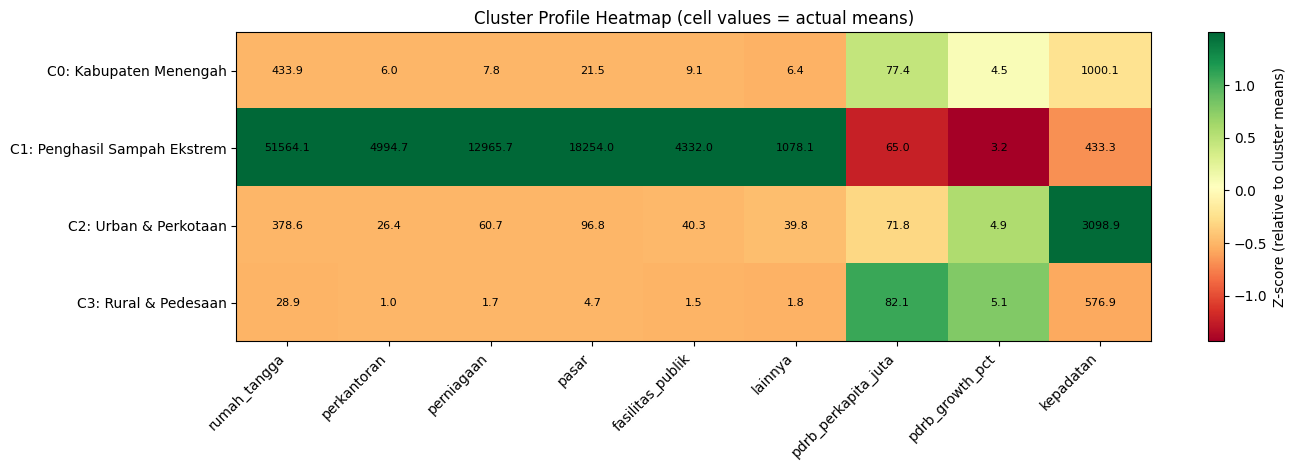

In [13]:
# Heatmap: normalized cluster means (z-score) to compare profiles
cluster_means = df_clean.groupby('cluster')[FEATURES].mean()
cluster_z = (cluster_means - cluster_means.mean()) / cluster_means.std()

# --- Cluster labeling based on relative ranking ---
cluster_sizes = df_clean['cluster'].value_counts()
waste_totals = cluster_means[SUMBER_COLS].sum(axis=1)
density_means = cluster_means['kepadatan']

CLUSTER_LABELS = {}
remaining = set(range(CHOSEN_K))

# 1. Outlier: very small cluster with extreme waste
for c in list(remaining):
    if cluster_sizes[c] <= 5 and waste_totals[c] > waste_totals.median() * 20:
        CLUSTER_LABELS[c] = 'Penghasil Sampah Ekstrem'
        remaining.discard(c)

# 2. Rank remaining by density and waste to assign labels
if remaining:
    ranked = sorted(remaining, key=lambda c: (density_means[c] + waste_totals[c].astype(float)), reverse=True)
    labels_pool = ['Urban & Perkotaan', 'Kabupaten Menengah', 'Rural & Pedesaan']
    # Distribute labels evenly across remaining clusters
    for i, c in enumerate(ranked):
        label_idx = min(i, len(labels_pool) - 1)
        CLUSTER_LABELS[c] = labels_pool[label_idx]

df_clean['cluster_label'] = df_clean['cluster'].map(CLUSTER_LABELS)

print('=== Cluster Labels ===')
for c in sorted(CLUSTER_LABELS):
    size = (df_clean['cluster'] == c).sum()
    wt = waste_totals[c]
    dens = density_means[c]
    print(f'  Cluster {c}: {CLUSTER_LABELS[c]:30s} ({size:3d} kabkota)  avg_waste={wt:10.1f}  avg_density={dens:.0f}')

# Heatmap with labeled y-axis
fig, ax = plt.subplots(figsize=(14, max(4, CHOSEN_K * 1.2)))
im = ax.imshow(cluster_z.values, cmap='RdYlGn', aspect='auto')

ax.set_xticks(range(len(FEATURES)))
ax.set_xticklabels(FEATURES, rotation=45, ha='right')
ax.set_yticks(range(CHOSEN_K))
ax.set_yticklabels([f'C{i}: {CLUSTER_LABELS[i]}' for i in range(CHOSEN_K)])

for i in range(CHOSEN_K):
    for j in range(len(FEATURES)):
        val = cluster_means.iloc[i, j]
        ax.text(j, i, f'{val:.1f}', ha='center', va='center', fontsize=8)

plt.colorbar(im, label='Z-score (relative to cluster means)')
ax.set_title('Cluster Profile Heatmap (cell values = actual means)')
plt.tight_layout()
plt.show()

## 10. PCA Visualization

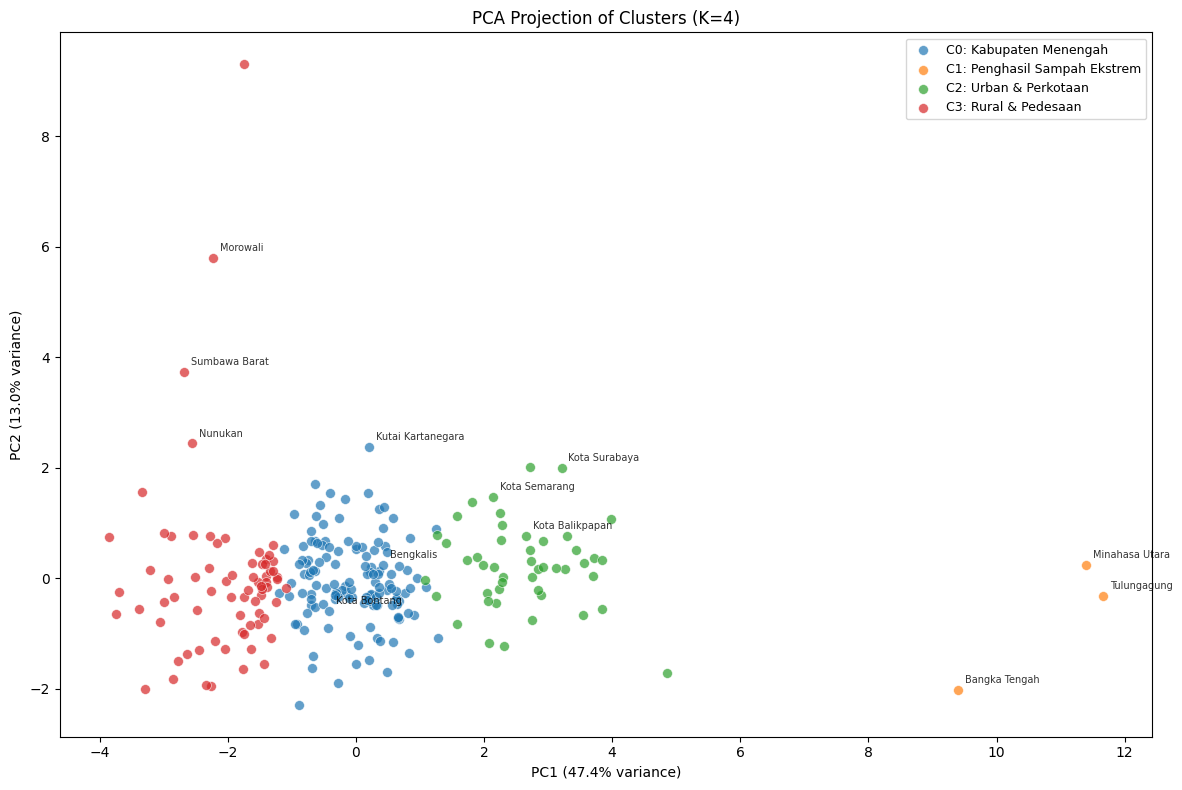

Explained variance: PC1=47.4%, PC2=13.0%
Total: 60.4%


In [14]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(12, 8))

# Plot each cluster with its label
for cluster_id in range(CHOSEN_K):
    mask = df_clean['cluster'] == cluster_id
    label = CLUSTER_LABELS[cluster_id]
    ax.scatter(X_pca[mask.values, 0], X_pca[mask.values, 1],
               alpha=0.7, s=50, edgecolors='white', linewidth=0.5,
               label=f'C{cluster_id}: {label}')

    # Label top 3 PDRB per cluster
    cluster_data = df_clean[mask]
    top3 = cluster_data.nlargest(3, 'pdrb_perkapita_juta').index
    for idx in top3:
        pos = df_clean.index.get_loc(idx)
        ax.annotate(df_clean.loc[idx, 'kabkota_display'],
                    (X_pca[pos, 0], X_pca[pos, 1]),
                    fontsize=7, alpha=0.8,
                    xytext=(5, 5), textcoords='offset points')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title(f'PCA Projection of Clusters (K={CHOSEN_K})')
ax.legend(loc='best', fontsize=9)
plt.tight_layout()
plt.show()

print(f'Explained variance: PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%}')
print(f'Total: {sum(pca.explained_variance_ratio_):.1%}')

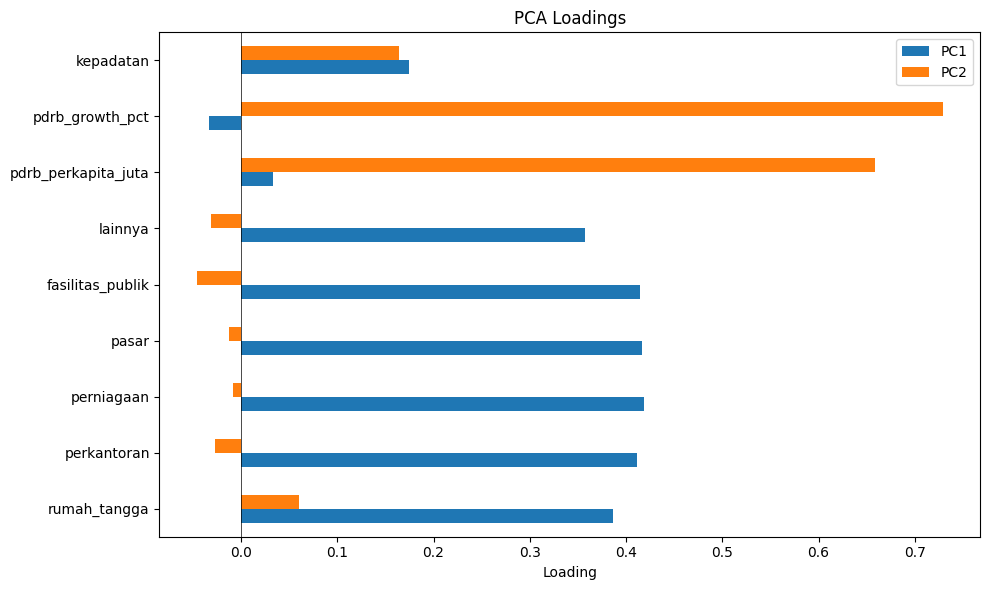

,PC1,PC2
rumah_tangga,0.386,0.060
perkantoran,0.411,-0.027
perniagaan,0.419,-0.008
pasar,0.417,-0.012
fasilitas_publik,0.415,-0.046
lainnya,0.357,-0.031
pdrb_perkapita_juta,0.033,0.659
pdrb_growth_pct,-0.033,0.729
kepadatan,0.174,0.164


In [15]:
# PCA loadings — which features drive each component?
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=FEATURES
).round(3)

fig, ax = plt.subplots(figsize=(10, 6))
loadings.plot(kind='barh', ax=ax)
ax.set_title('PCA Loadings')
ax.set_xlabel('Loading')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

display(loadings)

## 11. Daftar Kabupaten/Kota per Cluster

In [16]:
for c in range(CHOSEN_K):
    members = df_clean[df_clean['cluster'] == c].sort_values('pdrb_perkapita_juta', ascending=False)
    label = CLUSTER_LABELS[c]
    print(f'\n=== CLUSTER {c}: {label} ({len(members)} kabkota) ===')
    cols = ['kabkota_display', 'provinsi'] + FEATURES
    display(members[cols].head(15))


=== CLUSTER 0: Kabupaten Menengah (134 kabkota) ===


,kabkota_display,provinsi,rumah_tangga,perkantoran,perniagaan,pasar,fasilitas_publik,lainnya,pdrb_perkapita_juta,pdrb_growth_pct,kepadatan
200,Kutai Kartanegara,Kalimantan Timur,275.06,4.74,2.60,19.14,5.10,5.50,750.121442,5.614801,12.0
41,Bengkalis,Riau,43.75,12.50,5.00,17.50,11.25,2.50,373.473735,0.926605,60.0
207,Kota Bontang,Kalimantan Timur,82.20,5.06,0.00,5.91,3.03,3.80,367.569640,-2.509099,1173.0
236,Kolaka,Sulawesi Tenggara,78.39,3.62,6.03,18.09,10.85,2.41,318.304114,5.062496,71.0
208,Bulungan,Kalimantan Utara,16.77,5.95,11.18,13.97,5.59,0.00,311.862421,3.924875,2.0
42,Siak,Riau,17.50,5.00,2.00,7.00,4.50,1.00,294.040167,4.370168,31.0
199,Paser,Kalimantan Timur,97.10,2.43,5.46,10.32,2.43,1.21,186.923819,3.774674,28.0
201,Berau,Kalimantan Timur,65.55,1.58,5.30,8.66,3.85,4.06,186.218142,7.280445,12.0
50,Muara Enim,Sumatera Selatan,66.88,23.76,3.88,53.94,0.11,0.00,185.039227,5.890855,93.0
64,Lampung Timur,Lampung,12.50,3.40,5.60,75.50,0.00,3.00,184.489144,4.619122,146.0



=== CLUSTER 1: Penghasil Sampah Ekstrem (3 kabkota) ===


,kabkota_display,provinsi,rumah_tangga,perkantoran,perniagaan,pasar,fasilitas_publik,lainnya,pdrb_perkapita_juta,pdrb_growth_pct,kepadatan
213,Minahasa Utara,Sulawesi Utara,58315.00,12181.00,9947.00,11382.00,4994.00,1089.00,91.023732,5.206572,225.0
69,Bangka Tengah,Kepulauan Bangka Belitung,20755.38,830.22,1660.43,6226.61,2905.75,830.22,58.400047,-0.342753,89.0
118,Tulungagung,Jawa Timur,75621.82,1972.74,27289.61,37153.33,5096.25,1315.16,45.427924,4.859596,986.0



=== CLUSTER 2: Urban & Perkotaan (47 kabkota) ===


,kabkota_display,provinsi,rumah_tangga,perkantoran,perniagaan,pasar,fasilitas_publik,lainnya,pdrb_perkapita_juta,pdrb_growth_pct,kepadatan
141,Kota Surabaya,Jawa Timur,1343.76,29.53,37.59,111.68,12.18,12.98,258.543852,5.755207,8912.0
205,Kota Balikpapan,Kalimantan Timur,375.88,15.29,46.89,34.33,24.43,21.65,211.040932,3.226443,1427.0
102,Kota Semarang,Jawa Tengah,371.00,10.00,10.00,85.00,10.00,20.00,158.447993,5.684835,4565.0
98,Kudus,Jawa Tengah,239.52,14.94,25.76,90.56,30.85,20.94,148.177194,2.829681,1940.0
148,Badung,Bali,281.78,1.45,102.56,29.35,31.67,4.71,143.801351,5.943659,1309.0
115,Kota Yogyakarta,Daerah Istimewa Yogyakarta,191.61,0.93,55.09,27.35,8.33,17.25,119.646897,5.052934,12578.0
143,Kota Tangerang,Banten,1418.66,48.30,220.21,370.04,61.10,0.00,118.814853,5.039877,10608.0
206,Kota Samarinda,Kalimantan Timur,426.20,22.98,6.62,64.74,92.86,19.08,115.822056,8.662024,1185.0
107,Kota Surakarta,Jawa Tengah,148.51,74.26,74.26,2.75,3.44,54.46,110.780806,5.618190,12499.0
125,Mojokerto,Jawa Timur,472.17,24.79,70.83,159.35,28.33,17.71,99.681394,5.292368,1153.0



=== CLUSTER 3: Rural & Pedesaan (72 kabkota) ===


,kabkota_display,provinsi,rumah_tangga,perkantoran,perniagaan,pasar,fasilitas_publik,lainnya,pdrb_perkapita_juta,pdrb_growth_pct,kepadatan
209,Nunukan,Kalimantan Utara,11.24,0.29,0.56,1.69,0.89,0.12,1469.901281,4.066633,8.0
221,Morowali,Sulawesi Tengah,6.20,2.40,0.02,2.30,1.50,1.20,562.388369,16.260329,60.0
158,Sumbawa Barat,Nusa Tenggara Barat,7.80,0.32,0.32,2.70,0.50,0.00,248.153148,12.005026,85.0
245,Jayapura,Papua,82.00,0.27,2.40,9.00,7.00,0.01,166.708448,3.771770,0.0
233,Kota Makasar,Sulawesi Selatan,0.00,0.01,0.01,0.00,0.00,0.01,165.986154,5.560212,8229.0
52,Musi Banyuasin,Sumatera Selatan,5.00,0.10,0.20,15.00,4.00,0.00,134.500783,4.944960,48.0
203,Penajam Paser Utara,Kalimantan Timur,13.00,2.00,2.50,5.00,2.00,2.00,121.522241,30.681531,60.0
14,Aceh Tamiang,Aceh,3.25,2.20,5.32,12.87,4.04,0.00,119.042667,4.418456,25.0
214,Minahasa Tenggara,Sulawesi Utara,1.20,0.90,0.01,0.60,0.10,0.50,103.476933,5.368866,326.0
70,Bangka Barat,Kepulauan Bangka Belitung,80.00,1.77,0.27,0.30,0.29,0.00,95.909439,5.471960,57.0


## 12. Distribusi Fitur per Cluster

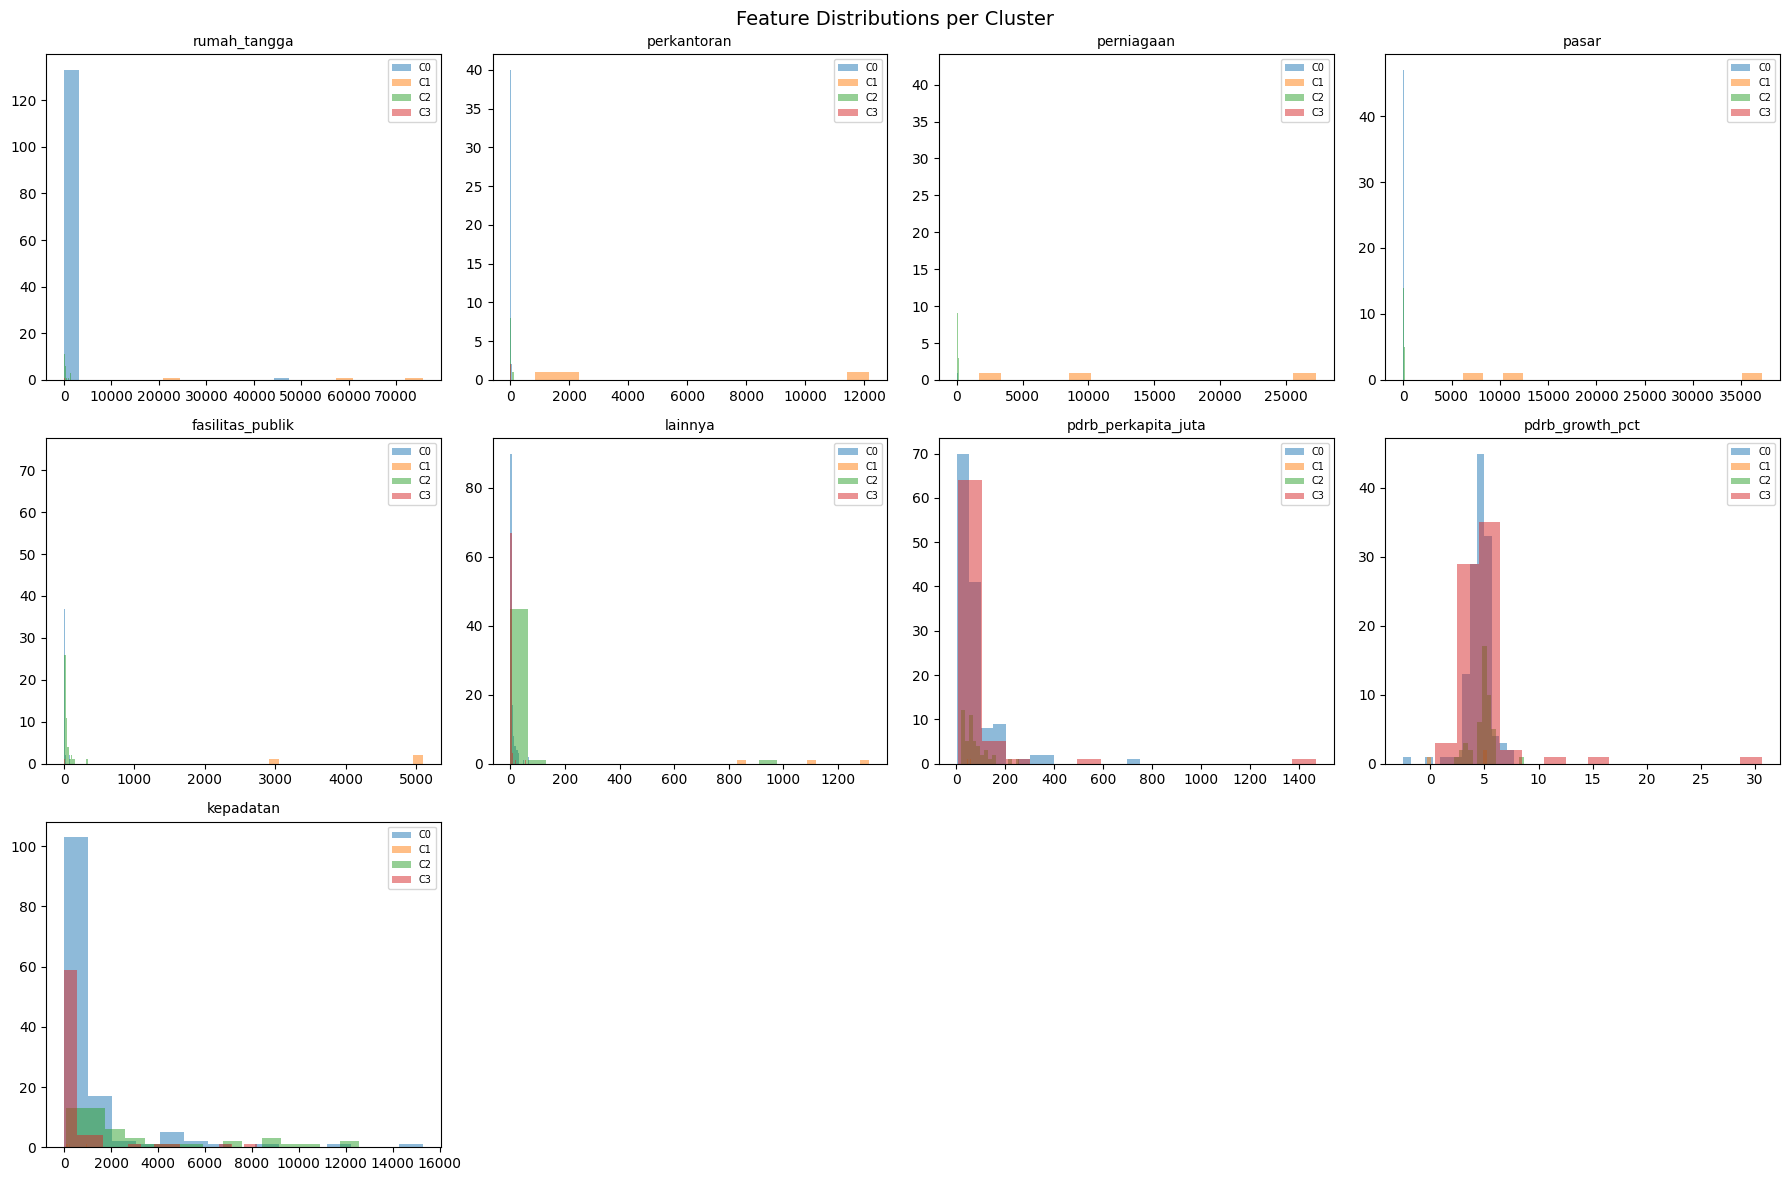

In [17]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    if i >= len(axes):
        break
    ax = axes[i]
    for c in range(CHOSEN_K):
        data = df_clean[df_clean['cluster'] == c][feat]
        ax.hist(data, bins=15, alpha=0.5, label=f'C{c}')
    ax.set_title(feat, fontsize=10)
    ax.legend(fontsize=7)

# Hide unused subplots
for j in range(len(FEATURES), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions per Cluster', fontsize=14)
plt.tight_layout()
plt.show()

## 13. Export Results

In [18]:
output_cols = ['kabkota_display', 'provinsi', 'cluster', 'cluster_label'] + FEATURES
output = df_clean[output_cols].sort_values(['cluster', 'kabkota_display']).copy()
output.columns = ['kabkota', 'provinsi', 'cluster', 'cluster_label'] + FEATURES

output_path = f'{BASE}/output/cluster_economic_sumber_2024.csv'

import os
os.makedirs(f'{BASE}/output', exist_ok=True)
output.to_csv(output_path, index=False)

print(f'Saved to {output_path}')
print(f'Total: {len(output)} kabkota in {CHOSEN_K} clusters')
print()
for c in sorted(CLUSTER_LABELS):
    size = (output['cluster'] == c).sum()
    print(f'  Cluster {c}: {CLUSTER_LABELS[c]} ({size} kabkota)')

Saved to ../data/output/cluster_economic_sumber_2024.csv
Total: 256 kabkota in 4 clusters

  Cluster 0: Kabupaten Menengah (134 kabkota)
  Cluster 1: Penghasil Sampah Ekstrem (3 kabkota)
  Cluster 2: Urban & Perkotaan (47 kabkota)
  Cluster 3: Rural & Pedesaan (72 kabkota)


## 14. Peta Cluster Kabupaten/Kota

In [19]:
import geopandas as gpd
from matplotlib.patches import Patch

# Load shapefile
gdf = gpd.read_file(f'{BASE}/../notebooks/shp/DUKCAPIL_KAB.shp')
gdf['kabkota_norm'] = gdf['nama_kab'].apply(normalize_name)

# Join cluster data to shapefile
gdf_merged = gdf.merge(
    df_clean[['kabkota_norm', 'cluster', 'cluster_label']],
    on='kabkota_norm',
    how='left'
)

matched = gdf_merged['cluster'].notna().sum()
total = len(gdf_merged)
print(f'Shapefile matched: {matched}/{total} kabkota')

missing_from_shp = set(df_clean['kabkota_norm']) - set(gdf['kabkota_norm'])
if missing_from_shp:
    print(f'Not found in shapefile ({len(missing_from_shp)}): {sorted(missing_from_shp)[:10]}')

/Users/macbook/MET-pipeline/met/lib/python3.9/site-packages/pyogrio/raw.py:198: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D Polygon' is converted to 'Polygon Z'
  return ogr_read(


Shapefile matched: 308/582 kabkota


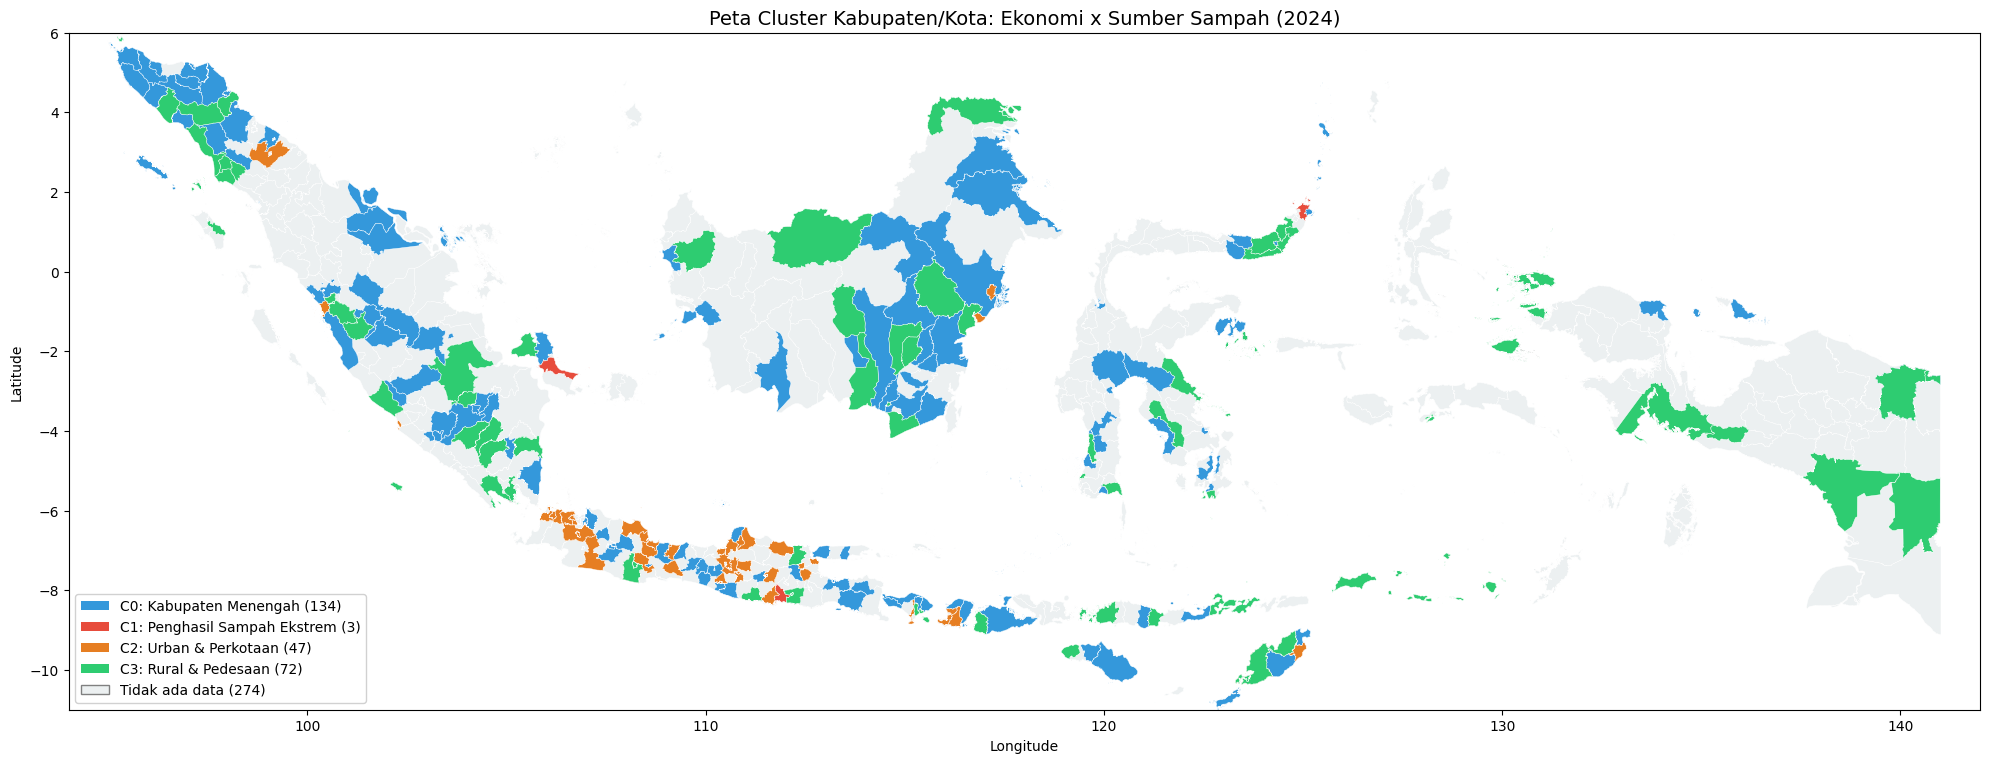

In [20]:
CLUSTER_COLORS = {
    0: '#3498db',  # blue   - Kabupaten Menengah
    1: '#e74c3c',  # red    - Penghasil Sampah Ekstrem
    2: '#e67e22',  # orange - Urban & Perkotaan
    3: '#2ecc71',  # green  - Rural & Pedesaan
}

fig, ax = plt.subplots(1, 1, figsize=(20, 12))

# Plot unmatched regions (grey)
gdf_merged[gdf_merged['cluster'].isna()].plot(
    ax=ax, color='#ecf0f1', edgecolor='white', linewidth=0.3
)

# Plot each cluster
for c in range(CHOSEN_K):
    subset = gdf_merged[gdf_merged['cluster'] == c]
    if len(subset) > 0:
        subset.plot(ax=ax, color=CLUSTER_COLORS[c], edgecolor='white', linewidth=0.3)

# Legend
legend_elements = [
    Patch(facecolor=CLUSTER_COLORS[c], label=f'C{c}: {CLUSTER_LABELS[c]} ({(df_clean["cluster"]==c).sum()})')
    for c in range(CHOSEN_K)
] + [Patch(facecolor='#ecf0f1', edgecolor='grey', label=f'Tidak ada data ({total - matched})')]

ax.legend(handles=legend_elements, loc='lower left', fontsize=10, framealpha=0.9)

ax.set_xlim(94, 142)
ax.set_ylim(-11, 6)
ax.set_title('Peta Cluster Kabupaten/Kota: Ekonomi x Sumber Sampah (2024)', fontsize=14)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()